# Initial Downloading, Wrangling, Loading, and Saving Data

To perform the RFM calculation, the data will first be downloaded and cleaned before being loaded for calculations.
Exploratory Data Analysis (EDA) will be performed on both datasets, tough the full dataset will get only surface-level check.

---

Online Retail II UCI – Dataset Features:
- Invoice – Invoice number (6-digit integral number uniquely assigned to each transaction. If starting with 'C', it indicates a cancellation)
- StockCode – Product (item) code (5-digit integral number uniquely assigned to each distinct product)
- Description – Product (item) name
- Quantity – The quantities of each product (item) per transaction
- InvoiceDate – Invoice date and time (the day and time when a transaction was generated)
- Price – Unit price (product price per unit in sterling £)
- Customer ID – Customer number (a 5-digit integral number uniquely assigned to each customer)
- Country – Country name (the name of the country where a customer resides)

### Initial Imports

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import squarify
import missingno as msno
from scipy import stats


# Local src
from src.utils.eda_utils import clean_column_names, df_overview
from src.tasks.download import download
from src.config.constants import DOWNLOAD_PATH

print('Done')

Done


In [2]:
BG = "#FDFDFD"       
TEXT_COLOR = "#2B2D42"   
GRID_COLOR = "#E2E8F0"  

PINK = "#FF1493"
GREEN = "#00FF41"
PURPLE = "#D100D1"
ORANGERED = "#FF4500"
BLUE = "#1E90FF"
HOTPINK = "#FF69B4"
ORANGE = "#FFA500"
DARKVIOLET = "#9400D3"
TOMATO = "#FF6347"
LIMEGREEN = "#32CD32"
LIGHTSEAGREEN = "#20B2AA"

plt.rcParams.update({
    "savefig.dpi": 300,      
    "savefig.bbox": "tight", 
    
    # Background & colors
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "axes.edgecolor": TEXT_COLOR,

    # Titles & labels
    "axes.titlesize": 18,
    "axes.titlepad": 16,
    "axes.labelsize": 13,
    "axes.labelpad": 10,
    "axes.labelweight": "medium",
    
    # Font
    "font.size": 12,
    "font.family": "Calibri",

    # Lines
    "lines.linewidth": 2.5,
    "lines.markersize": 7,    

    # Grid
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.alpha": 0.6,   
    "grid.linewidth": 0.8,
    "grid.linestyle": "--",
    "axes.axisbelow": True,   

    # Figure
    "figure.figsize": (10, 6),
    "figure.autolayout": False,

    # Spines
    "axes.linewidth": 1.2,

    # Legend
    "legend.facecolor": "#f7f7f7",
    "legend.edgecolor": TEXT_COLOR,
    "legend.framealpha": 1.0,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

sns.set_theme(
    style="whitegrid", 
    context="notebook",  
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 3)

print('Done')

Done


## Data Acquisition

### Data Downloading and Loading

In [3]:
download(DOWNLOAD_PATH)

2026-04-26 19:53:57 | INFO    | src.tasks.download | Data exists in D:\projects\customer-rfm-segmentation-dashboard\data\01_raw. Skipping.


In [4]:
path_csv = '../data/01_raw/online_retail_II.csv'
df = pd.read_csv(path_csv)
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,"12,680.000",France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,"12,680.000",France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,"12,680.000",France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.950,"12,680.000",France


### Data Cleaning

In [5]:
df = clean_column_names(df)
df.columns

Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'price', 'customer_id', 'country'], dtype='object')

In [6]:
df_overview(df)

================================= Shape =================================
(1067371, 8)
================================= Info =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice       1067371 non-null  object 
 1   stock_code    1067371 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1067371 non-null  int64  
 4   invoice_date  1067371 non-null  object 
 5   price         1067371 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
================================= Columns =================================
Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'price', 'customer_id', 'country'], dtype='object')
=======

- It shows that price and quantity takes minus values in the dataset; 
- the column customer_id is float;
- the column invoice_date is object;
- 243k missing customer IDs and 4k of descriptions;
- negative values in price & quantity columns;
- 1m+ total records;
- quantities take large numbers 81k;
- 34k of duplicates;

In [7]:
print(df['customer_id'].isnull().sum() / df.shape[0])
print(df['description'].isnull().sum() / df.shape[0])

0.22766872999172733
0.0041054141437232225


- 22.8% of customer IDs are NaNs;
- 0.4% of descriptions are NaNs;

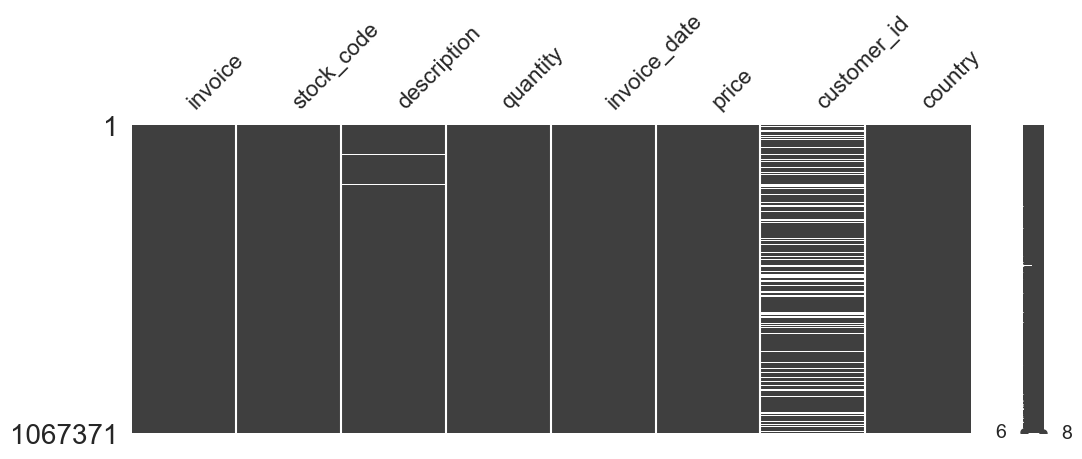

In [8]:
msno.matrix(df, figsize=(12, 4))
plt.show()

- the missing values in customer_id can be guests, they spread across invoices;
- needs to check if concentrated in certain periods;
- needs to check geographic of the missing customer_ids;
- needs to check the products in the transactions with missing customer_ids;

In [9]:
df_missing_ids = df[df['customer_id'].isnull()]
missing_ids_country = df_missing_ids['country'].value_counts().head(20)
missing_ids_description = df_missing_ids['description'].value_counts().head(20)
df_missing_ids['invoice_date'] = pd.to_datetime(df_missing_ids['invoice_date'])
df_missing_ids['year_month_day'] = df_missing_ids['invoice_date'].dt.to_period('D')
df_missing_ids['year_month'] = df_missing_ids['invoice_date'].dt.to_period('M')

missing_ids_day = df_missing_ids['year_month_day'].value_counts().sort_values().tail(20)
missing_ids_month = df_missing_ids['year_month'].value_counts().sort_values().tail(20)
print("Top 20 countries with missing customer_id:")
print(missing_ids_country)
print("\nTop 20 descriptions with missing customer_id:")
print(missing_ids_description)
print("\nMissing customer_id counts by day:")
print(missing_ids_day)
print("\nMissing customer_id counts by month:")
print(missing_ids_month)


Top 20 countries with missing customer_id:
country
United Kingdom          240029
EIRE                      1671
Hong Kong                  364
Unspecified                232
France                     128
Switzerland                125
Portugal                   116
United Arab Emirates       114
Bahrain                     67
Israel                      47
RSA                         46
Bermuda                     34
Sweden                      19
Lebanon                     13
Nigeria                      2
Name: count, dtype: int64

Top 20 descriptions with missing customer_id:
description
DOTCOM POSTAGE                        1428
JUMBO BAG RED RETROSPOT                693
JUMBO STORAGE BAG SUKI                 635
REGENCY CAKESTAND 3 TIER               635
PARTY BUNTING                          621
WHITE HANGING HEART T-LIGHT HOLDER     603
RECYCLING BAG RETROSPOT                573
JUMBO SHOPPER VINTAGE RED PAISLEY      529
WOODLAND CHARLOTTE BAG                 526
JUMBO BAG WO

C:\Users\zxrco\AppData\Local\Temp\ipykernel_3828\4139574273.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing_ids['invoice_date'] = pd.to_datetime(df_missing_ids['invoice_date'])
C:\Users\zxrco\AppData\Local\Temp\ipykernel_3828\4139574273.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing_ids['year_month_day'] = df_missing_ids['invoice_date'].dt.to_period('D')
C:\Users\zxrco\AppData\Local\Temp\ipykernel_3828\4139574273.py:6: SettingWithCopyWarning: 
A value is trying to be set on a 

- no clear pattern in geographic;
- no clear pattern in products;
- some months are clearly having more transactions without customer id:
  - 2009-12    13468
  - 2010-11    16525
  - 2011-11    19113
  - 2010-12    23351
- but still no pattern, the more transactions without customer id might be because these months have overall more transactions;
- so the desicion is to drop them for rfm, but keep for the analysis;

### Analysis of Negative and Zero Values in Quantities & Prices

Check the frequency of negative or zero values in the dataset to determine their impact and decide on an appropriate handling strategy (e.g., removal or imputation).

In [10]:
print(df.loc[df['quantity'] < 0].shape)
print(df.loc[df['quantity'] == 0].shape)
print(df.loc[df['price'] < 0].shape)
print(df.loc[df['price'] == 0].shape)

(22950, 8)
(0, 8)
(5, 8)
(6202, 8)


- 23k of entries where quantity is negative; either logging/other issues or refunds
- 6k of entries where price is negative; probably logging/other issues

In [11]:
df.loc[df['quantity'] < 0, :]

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.950,"16,321.000",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.650,"16,321.000",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.250,"16,321.000",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.100,"16,321.000",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.950,"16,321.000",Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.830,"14,397.000",United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.690,"15,498.000",United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.950,"15,311.000",United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.250,"17,315.000",United Kingdom


- invoice starts with C in quantity < 0, can be mark of cancellation and return;

In [12]:
df.loc[(df['invoice'].str.startswith('C', na=False)) & (df['quantity'] > 0)]

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.570,NaN,United Kingdom


- only one entry with C that has positive quantity;

In [13]:
negative_price = df.loc[df['price'] < 0, :]
print(negative_price)
negative_price['description'].value_counts().head(20)

        invoice stock_code      description  quantity         invoice_date       price  customer_id         country
179403  A506401          B  Adjust bad debt         1  2010-04-29 13:36:00 -53,594.360          NaN  United Kingdom
276274  A516228          B  Adjust bad debt         1  2010-07-19 11:24:00 -44,031.790          NaN  United Kingdom
403472  A528059          B  Adjust bad debt         1  2010-10-20 12:04:00 -38,925.870          NaN  United Kingdom
825444  A563186          B  Adjust bad debt         1  2011-08-12 14:51:00 -11,062.060          NaN  United Kingdom
825445  A563187          B  Adjust bad debt         1  2011-08-12 14:52:00 -11,062.060          NaN  United Kingdom


description
Adjust bad debt    5
Name: count, dtype: int64

- it is an adjust bad debt, but the customer_id is not defined for these transactions, it will not be dropped, but will be calculated in the revenue;
- if there is negative price & negative qty, should be handled;

In [14]:
zero_price = df.loc[df['price'] == 0, :]
print(zero_price)
zero_price['description'].value_counts().head(20)

        invoice stock_code                   description  quantity         invoice_date  price  customer_id         country
263      489464      21733                  85123a mixed       -96  2009-12-01 10:52:00  0.000          NaN  United Kingdom
283      489463      71477                         short      -240  2009-12-01 10:52:00  0.000          NaN  United Kingdom
284      489467     85123A                   21733 mixed      -192  2009-12-01 10:53:00  0.000          NaN  United Kingdom
470      489521      21646                           NaN       -50  2009-12-01 11:44:00  0.000          NaN  United Kingdom
3114     489655      20683                           NaN       -44  2009-12-01 17:26:00  0.000          NaN  United Kingdom
...         ...        ...                           ...       ...                  ...    ...          ...             ...
1062442  581234      72817                           NaN        27  2011-12-08 10:33:00  0.000          NaN  United Kingdom
1063965 

description
check                                  162
?                                       92
damages                                 84
damaged                                 81
found                                   28
missing                                 27
sold as set on dotcom                   20
Damaged                                 17
adjustment                              16
OWL DOORSTOP                            15
POLYESTER FILLER PAD 45x45cm            12
dotcom                                  12
amazon                                  11
FRENCH BLUE METAL DOOR SIGN 1           10
IVORY KITCHEN SCALES                    10
POLYESTER FILLER PAD 40x40cm            10
AIRLINE BAG VINTAGE WORLD CHAMPION       9
RED KITCHEN SCALES                       9
BOX OF 24 COCKTAIL PARASOLS              9
PICNIC BASKET WICKER LARGE               9
Name: count, dtype: int64

- it is various things, but it is not worth including into analysis, as it will add a large complexity layer;

In [15]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.950,"16,329.000",United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.950,"16,329.000",United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.750,"16,329.000",United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.750,"16,329.000",United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.750,"16,329.000",United Kingdom
...,...,...,...,...,...,...,...,...
965610,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.950,"15,110.000",United Kingdom
986868,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.550,"17,838.000",United Kingdom
986869,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.550,"17,838.000",United Kingdom
1055441,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.950,"14,562.000",United Kingdom


- duplicates can be due to logging issues.

In [16]:
#df = df[df['quantity'] > 0].copy()
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['description'] = df['description'].str.strip()

- converted customer_id column type from float to int for sql loading;
- converted invoice_date column type to datetime for plotting;

In [17]:
print(f"Before: {len(df)}")
df = df[df['price'] != 0].copy()
print(f"After dropping zero prices: {len(df)}")

Before: 1067371
After dropping zero prices: 1061169


- dropped zero values from price column;

In [18]:
print(f"Before: {len(df)}")
df = df.drop(df.loc[(df['invoice'].str.startswith('C', na=False)) & (df['quantity'] > 0)].index).copy()
print(f"After dropping 'C' invoices with positive quantity: {len(df)}")

Before: 1061169
After dropping 'C' invoices with positive quantity: 1061168


- dropped transactions with return & positive qty;

In [19]:
print(f"Before: {len(df)}")
df = df.drop_duplicates().copy()
print(f"After dropping duplicates: {len(df)}")

Before: 1061168
After dropping duplicates: 1027021


- dropped duplicates, as they are probably system log issues;

In [20]:
tmp = df.sort_values(by='price', ascending=False)
print(tmp['description'].head(5000).unique().tolist())
print(tmp['stock_code'].head(5000).unique().tolist())

['Manual', 'Bank Charges', 'AMAZON FEE', 'Adjust bad debt', 'POSTAGE', 'Adjustment by john on 26/01/2010 17', 'DOTCOM POSTAGE', 'Discount', 'FLAG OF ST GEORGE CAR FLAG', 'CRUK Commission', 'PICNIC BASKET WICKER 60 PIECES', 'SAMPLES', 'Adjustment by Peter on Jun 25 2010', 'Adjustment by Peter on 24/05/2010 1', 'Adjustment by john on 26/01/2010 16', 'VINTAGE RED KITCHEN CABINET', 'VINTAGE BLUE KITCHEN CABINET', 'LOVE SEAT ANTIQUE WHITE METAL', 'RUSTIC  SEVENTEEN DRAWER SIDEBOARD', 'REGENCY MIRROR WITH SHUTTERS', 'GIANT SEVENTEEN DRAWER SIDEBOARD', 'CARRIAGE', 'BLUE KASHMIRI COFFEE TABLE', 'FRENCH STYLE WALL DRESSER', 'CHEST NATURAL WOOD 20 DRAWERS', 'ANT WHITE SWEETHEART TABLE W 3 DRAW', 'ANTIQUE EDWARDIAN DRESSER', 'METAL WALL SHELF UNIT WITH HOOKS', 'HALL CABINET WITH 3 DRAWERS', 'CINDERELLA CHANDELIER', 'SWEETHEART CREAM STEEL TABLE RECT', 'BLUE GINGHAM ROSE QUILT', 'GREEN ROSE QUILT', 'PINK AND LILAC QUILTED THROW', 'FLAG OF ST GEORGE', 'ENGLISH ROSE DESIGN QUILTED THROW', 'Dotcomgif

- checked unique description & stock_code to identify invalid transactions for the analysis and modeling;
- adjustments, postage, manual, discount, dotcom postage, post, d, dot, adjust, m, cruk, c2, carriage, bank charges, amazonfee seem invalid;

In [21]:
df[df['stock_code'] == 'C2']

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
9292,490127,C2,CARRIAGE,1,2009-12-03 18:13:00,50.000,"14,156.000",EIRE
14481,490541,C2,CARRIAGE,1,2009-12-07 09:25:00,50.000,NaN,EIRE
14502,490542,C2,CARRIAGE,1,2009-12-07 09:42:00,50.000,"14,911.000",EIRE
19541,490998,C2,CARRIAGE,1,2009-12-08 17:24:00,50.000,"16,253.000",United Kingdom
22803,491160,C2,CARRIAGE,1,2009-12-10 10:29:00,50.000,"14,911.000",EIRE
...,...,...,...,...,...,...,...,...
1040462,579768,C2,CARRIAGE,1,2011-11-30 15:08:00,50.000,"14,911.000",EIRE
1041945,579910,C2,CARRIAGE,1,2011-12-01 08:52:00,50.000,"14,911.000",EIRE
1044315,580124,C2,CARRIAGE,1,2011-12-01 17:12:00,50.000,NaN,EIRE
1044366,580127,C2,CARRIAGE,1,2011-12-01 17:51:00,50.000,"14,911.000",EIRE


In [22]:
"""
for non-product removal, so analysis can be focused on actual products.

 non_product_keywords = [
    'manual', 
    'postage', 
    'dotcom postage', 
    'bank charges', 
    'amazon fee', 
    'discount',
    'adjust',
    'carriage'
]
non_product_codes = ['POST', 'DOT', 'M', 'D', 'C2', 'AMAZONFEE', 
                     'BANK CHARGES', 'CRUK']
print(f"Before: {len(df)}")
df = df[~df['stock_code'].isin(non_product_codes)]
print(f"After removing rows with non-product codes: {len(df)}")

additional_non_product_keywords = ['adjust']

print(f"Before: {len(df)}")
pattern = '|'.join(non_product_keywords)
df = df[~df['description'].str.lower().str.contains(pattern, na=False)].copy()
print(f"After removing rows with non-product descriptions: {len(df)}") 
"""

'\nfor non-product removal, so analysis can be focused on actual products.\n\n non_product_keywords = [\n    \'manual\', \n    \'postage\', \n    \'dotcom postage\', \n    \'bank charges\', \n    \'amazon fee\', \n    \'discount\',\n    \'adjust\',\n    \'carriage\'\n]\nnon_product_codes = [\'POST\', \'DOT\', \'M\', \'D\', \'C2\', \'AMAZONFEE\', \n                     \'BANK CHARGES\', \'CRUK\']\nprint(f"Before: {len(df)}")\ndf = df[~df[\'stock_code\'].isin(non_product_codes)]\nprint(f"After removing rows with non-product codes: {len(df)}")\n\nadditional_non_product_keywords = [\'adjust\']\n\nprint(f"Before: {len(df)}")\npattern = \'|\'.join(non_product_keywords)\ndf = df[~df[\'description\'].str.lower().str.contains(pattern, na=False)].copy()\nprint(f"After removing rows with non-product descriptions: {len(df)}") \n'

- if need to drop non-product transactions;

In [23]:
tmp = df.sort_values(by='quantity', ascending=False)
print(tmp[['description', 'stock_code', 'price', 'quantity']].head(50))
print(tmp[['description', 'stock_code', 'price', 'quantity']].tail(50))

                                 description stock_code  price  quantity
1065882          PAPER CRAFT , LITTLE BIRDIE      23843  2.080     80995
587080        MEDIUM CERAMIC TOP STORAGE JAR      23166  1.040     74215
90857     BLACK AND WHITE PAISLEY FLOWER MUG      37410  0.100     19152
127166           SET/6 STRAWBERRY PAPER CUPS      21099  0.100     12960
127168           SET/6 WOODLAND PAPER PLATES      21091  0.100     12960
127169             SET/6 WOODLAND PAPER CUPS      21085  0.100     12744
127167         SET/6 STRAWBERRY PAPER PLATES      21092  0.100     12480
135027       PACK OF 12 PINK PAISLEY TISSUES      21984  0.250     10000
135028               PACK OF 12 SUKI TISSUES      21982  0.250     10000
135030           PACK OF 12 WOODLAND TISSUES      21981  0.250     10000
135029         PACK OF 12 RED SPOTTY TISSUES      21980  0.250     10000
93677        SMALL FAIRY CAKE FRIDGE MAGNETS      85220  0.300      9456
432176   ROTATING SILVER ANGELS T-LIGHT HLDR      8

- huge positive & negative quantities are valid, as they capture regular purchases & returns;

In [24]:
df['revenue'] = df['quantity'] * df['price']
df.groupby('customer_id')['revenue'].sum().describe()

count     5,939.000
mean      2,742.885
std      13,679.955
min     -25,111.090
25%         321.365
50%         823.530
75%       2,143.280
max     570,380.610
Name: revenue, dtype: float64

- some of our customers are having negative revenue, probably data on their initial purchase was not collected, but return was; 
- it is still suitable for analysis, even rfm;

In [25]:
tmp = df.groupby('customer_id')['revenue'].sum().reset_index()
negative_ids = tmp['customer_id'][tmp['revenue'] < 0]
negative_ids

0      12,346.000
36     12,382.000
360    12,706.000
550    12,896.000
572    12,918.000
          ...    
5312   17,661.000
5406   17,755.000
5594   17,943.000
5674   18,023.000
5723   18,072.000
Name: customer_id, Length: 84, dtype: float64

In [26]:
print(df[['country', 'revenue', 'invoice_date']].sort_values(by='invoice_date', ascending=False).head(50))
print(df[['country', 'revenue', 'invoice_date']].sort_values(by='invoice_date', ascending=False).tail(50))

                country  revenue        invoice_date
1067370          France   18.000 2011-12-09 12:50:00
1067362          France   15.600 2011-12-09 12:50:00
1067355          France   23.400 2011-12-09 12:50:00
1067357          France   19.800 2011-12-09 12:50:00
1067358          France   15.000 2011-12-09 12:50:00
1067359          France   15.000 2011-12-09 12:50:00
1067360          France   15.000 2011-12-09 12:50:00
1067361          France   15.000 2011-12-09 12:50:00
1067356          France   19.800 2011-12-09 12:50:00
1067363          France   23.400 2011-12-09 12:50:00
1067365          France   10.200 2011-12-09 12:50:00
1067366          France   12.600 2011-12-09 12:50:00
1067367          France   16.600 2011-12-09 12:50:00
1067368          France   16.600 2011-12-09 12:50:00
1067364          France   16.600 2011-12-09 12:50:00
1067369          France   14.850 2011-12-09 12:50:00
1067353  United Kingdom  214.800 2011-12-09 12:49:00
1067352  United Kingdom   30.000 2011-12-09 12

- the records start and end smoothly, in Dec, right before New Year;

In [27]:
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
df['day'] = df['invoice_date'].dt.day
df['hour'] = df['invoice_date'].dt.hour
df['day_of_week'] = df['invoice_date'].dt.day_name()

print(df.columns)
df

Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'price', 'customer_id', 'country',
       'revenue', 'year', 'month', 'day', 'hour', 'day_of_week'],
      dtype='object')


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue,year,month,day,hour,day_of_week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom,83.400,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom,81.000,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom,81.000,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom,100.800,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom,30.000,2009,12,1,7,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,"12,680.000",France,12.600,2011,12,9,12,Friday
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,"12,680.000",France,16.600,2011,12,9,12,Friday
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,"12,680.000",France,16.600,2011,12,9,12,Friday
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.950,"12,680.000",France,14.850,2011,12,9,12,Friday


- created month, day, hour, day_of_week for richer and deeper analysis;

In [28]:
for col in ['quantity', 'price', 'revenue']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

quantity: 111527 outliers (10.9%)
price: 66195 outliers (6.4%)
revenue: 89004 outliers (8.7%)


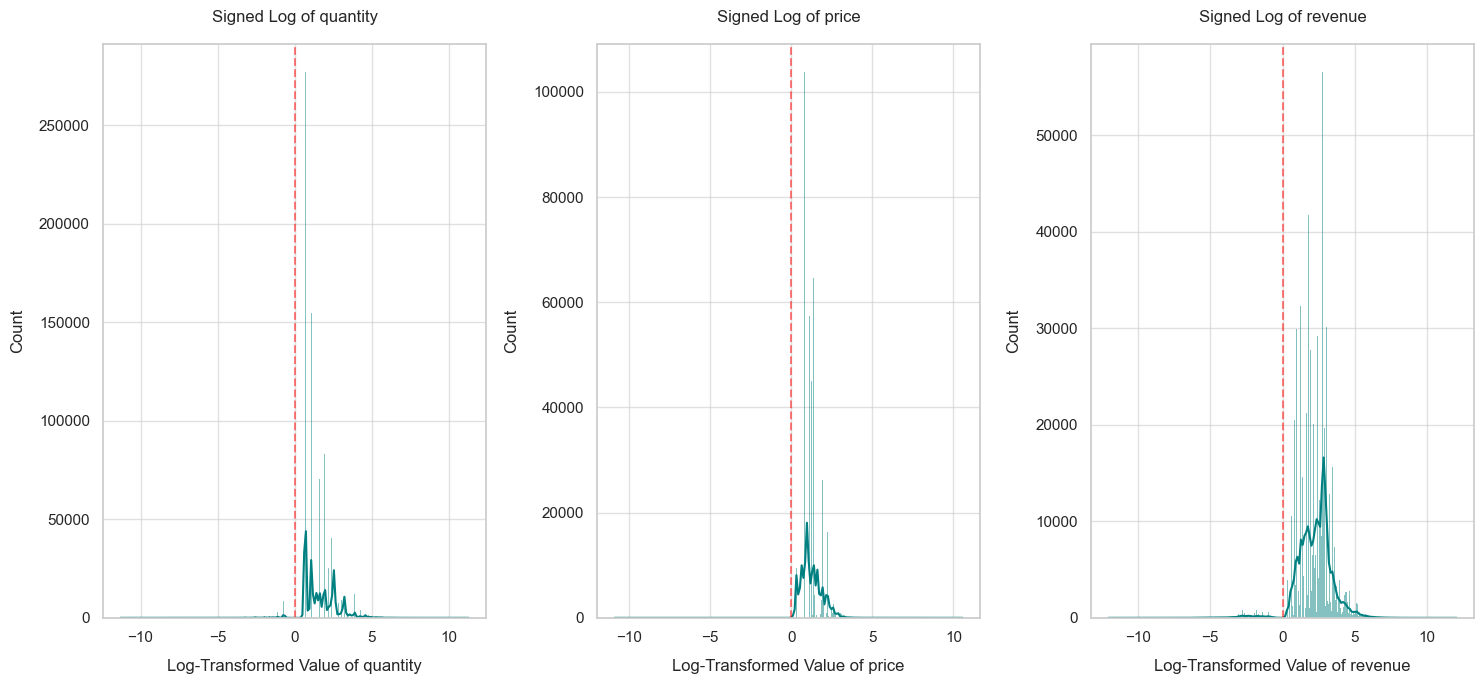

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

dist_cols = ['quantity', 'price', 'revenue']


for i, col in enumerate(dist_cols):
    log_data = np.sign(df[col]) * np.log1p(df[col].abs()) 
    
    sns.histplot(log_data, kde=True, ax=axes[i], color='teal')
    
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    
    axes[i].set_title(f"Signed Log of {col}")
    axes[i].set_xlabel(f"Log-Transformed Value of {col}")

plt.tight_layout()
plt.show()

2026-04-26 19:54:16 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 19:54:16 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


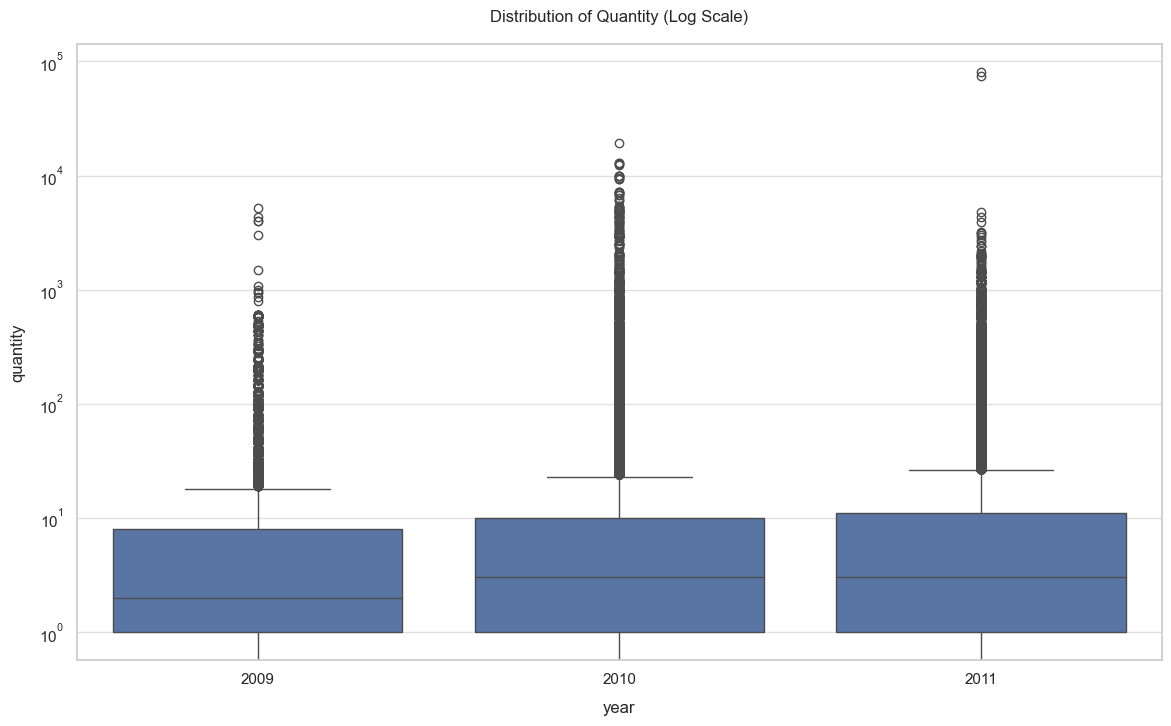

In [30]:
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='year', y='quantity', data=df)

ax.set_yscale("log") 

plt.title('Distribution of Quantity (Log Scale)')
plt.show()

- the amount of transaction with greater quantity grow every year, would like to look at that using heatmap (revenue);

- see a lot of outliers, but can be used NTILE (SQL) and qcut (pandas) to handle them when calculating rfm; (monetary will be huge and without handling it only the big players will be marked as valuable);

2026-04-26 19:54:17 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 19:54:17 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


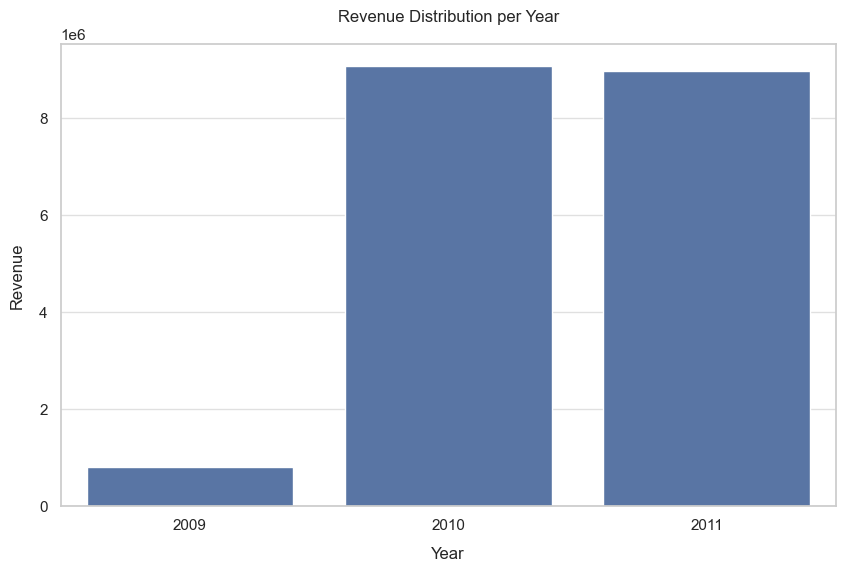

In [31]:
year_rev = df.groupby('year')['revenue'].sum()

sns.barplot(x=year_rev.index, y=year_rev.values)
plt.title('Revenue Distribution per Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

- the total revenue are roughly the same for 2010 (1) and 2011 (2);
- the 2009 revenue is not captured well in the records;

2026-04-26 19:54:17 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 19:54:17 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'Monthly Revenue Trend')

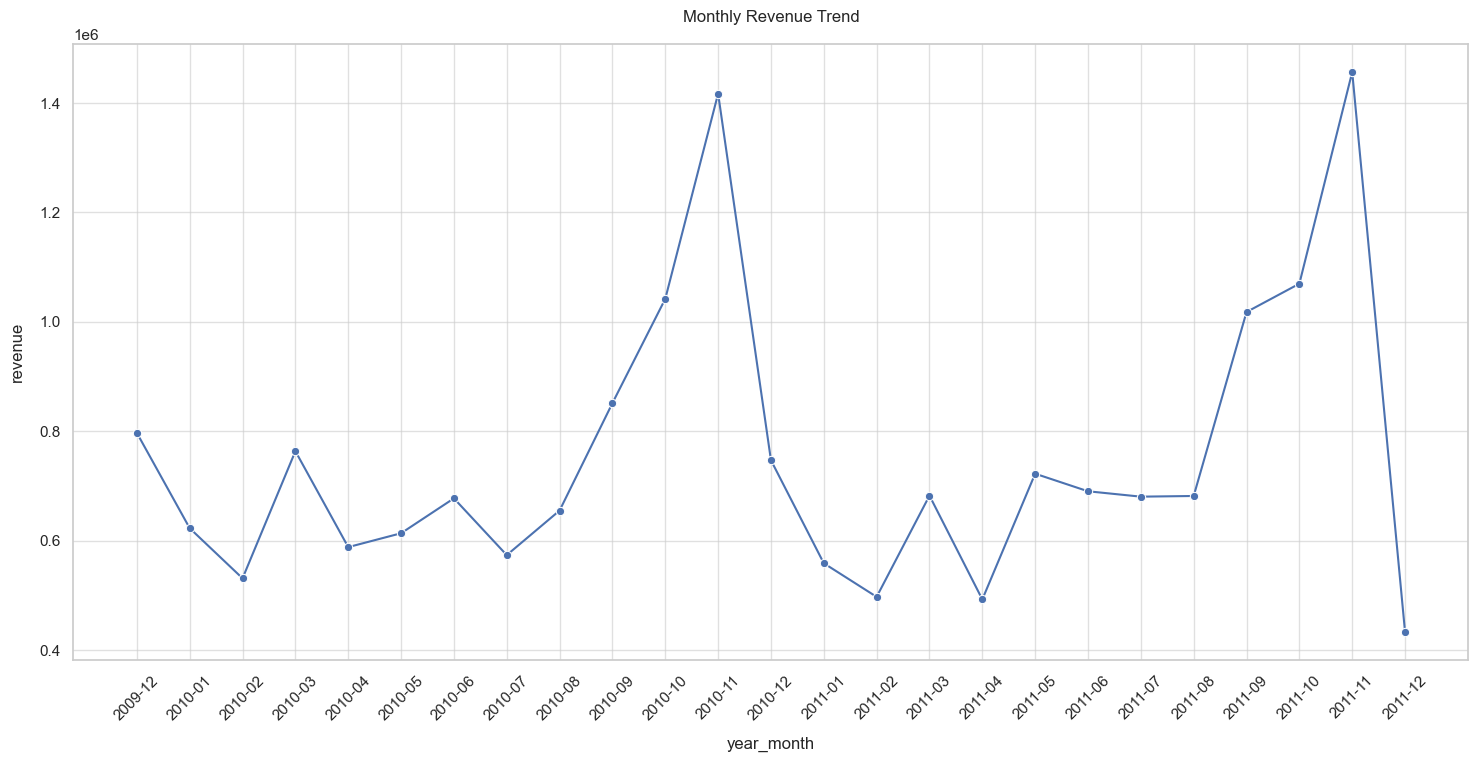

In [32]:
year_month_rev = df.groupby(['year','month'])['revenue'].sum().reset_index()
year_month_rev['year_month'] = year_month_rev['year'].astype(str) + '-' + year_month_rev['month'].astype(str).str.zfill(2)
year_month_rev = year_month_rev.sort_values('year_month')

plt.figure(figsize=(18, 8))
sns.lineplot(data=year_month_rev, x='year_month', y='revenue', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')

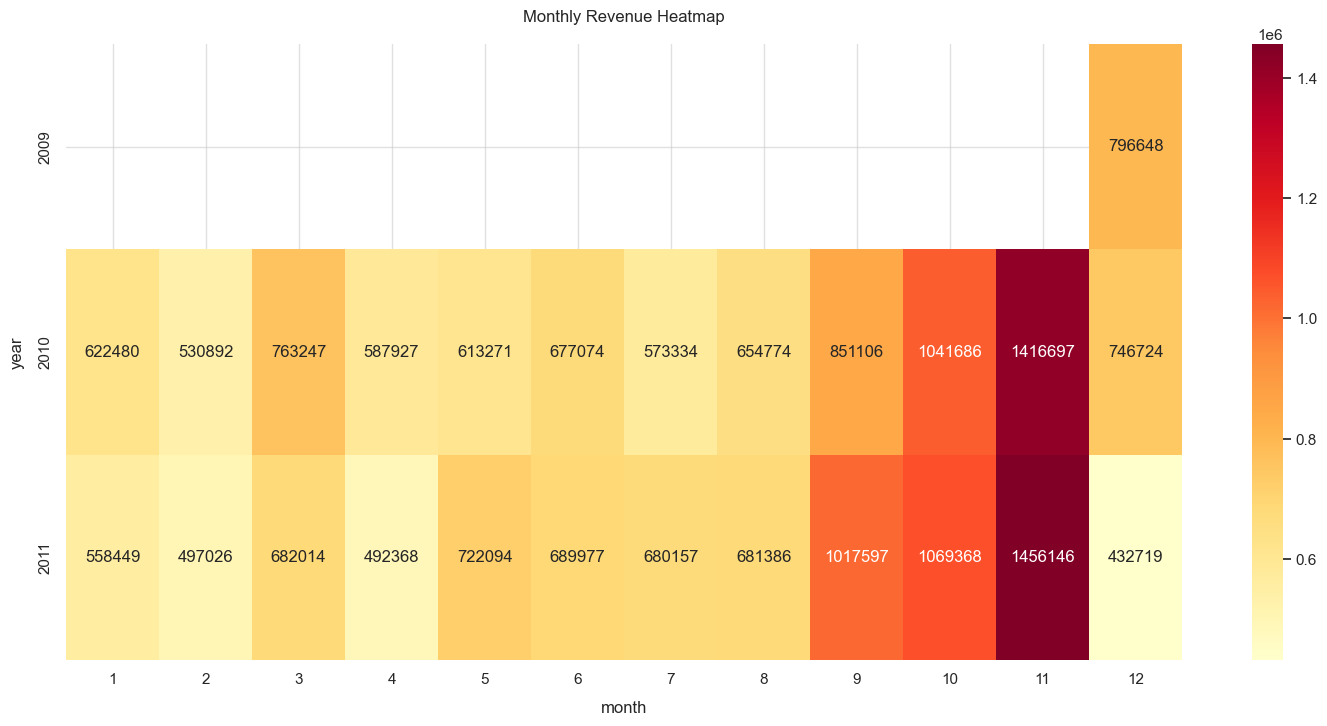

In [33]:
pivot_rev = year_month_rev.pivot(index='year', columns='month', values='revenue')

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_rev, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title('Monthly Revenue Heatmap')
plt.show()

- see 2 spikes of monthly revenue in Oct-Nov in years 2010 and 2011; can be due to purchases before New Year; (pre-holiday surge)
- see 2 huge drop of monthly revenue in Dec in years 2010 and 2011;
- want to compare with day of month revenue heatmaps;

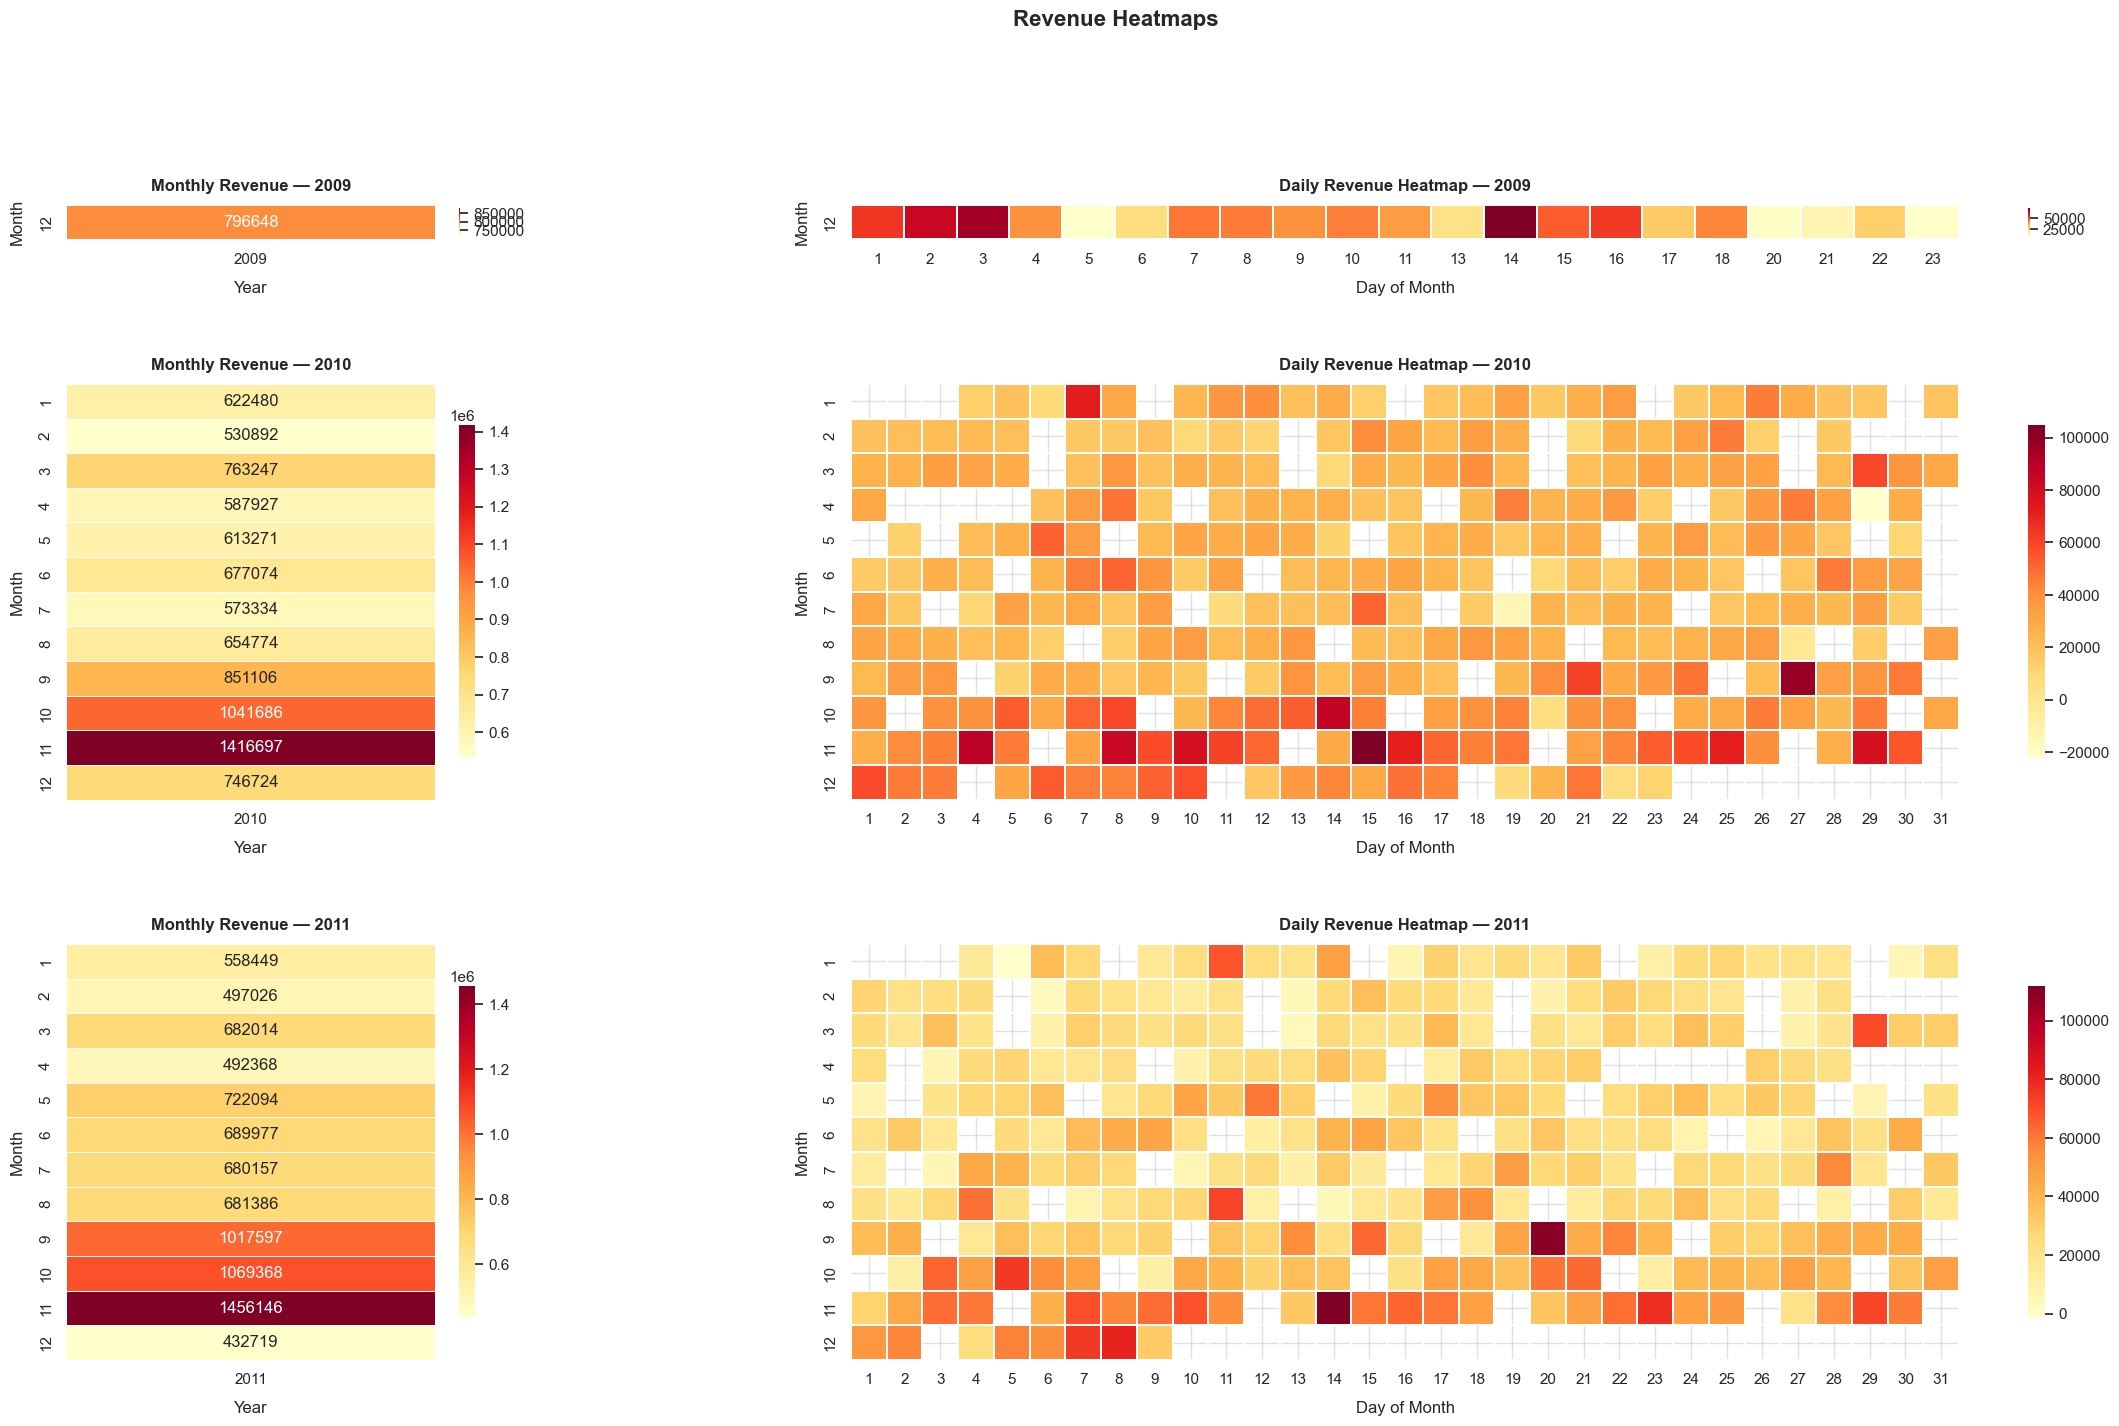

In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

years = sorted(df['year'].unique())

# Count months per year for proportional row heights
month_counts = {year: df[df['year'] == year]['month'].nunique() for year in years}
height_ratios = [month_counts[y] for y in years]

pivot_rev = year_month_rev.pivot(index='month', columns='year', values='revenue')

fig = plt.figure(figsize=(28, sum(height_ratios) * 0.6))
gs = gridspec.GridSpec(
    len(years), 2,
    figure=fig,
    width_ratios=[0.6, 1.8],
    height_ratios=height_ratios,
    hspace=0.5,
    wspace=0.35
)

for i, year in enumerate(years):
    n_months = month_counts[year]

    # ── LEFT: monthly revenue bar-style heatmap ────────────────────────────────
    ax_left = fig.add_subplot(gs[i, 0])
    year_slice = pivot_rev[[year]].dropna()

    sns.heatmap(
        year_slice,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax_left,
        cbar=True,
        cbar_kws={'shrink': 0.8},
        yticklabels=year_slice.index  # only show months that exist
    )
    ax_left.set_title(f'Monthly Revenue — {year}', fontsize=12, fontweight='bold', pad=10)
    ax_left.set_xlabel('Year')
    ax_left.set_ylabel('Month')
    ax_left.tick_params(axis='x', rotation=0)

    # ── RIGHT: day-of-month heatmap ────────────────────────────────────────────
    ax_right = fig.add_subplot(gs[i, 1])

    year_data = df[df['year'] == year]
    pivot_day = (
        year_data
        .groupby(['month', 'day'])['revenue']
        .sum()
        .reset_index()
        .pivot(index='month', columns='day', values='revenue')
    )

    sns.heatmap(
        pivot_day,
        annot=False,
        cmap='YlOrRd',
        linewidths=0.3,
        ax=ax_right,
        cbar_kws={'shrink': 0.8},
        yticklabels=pivot_day.index  # only show months that exist
    )
    ax_right.set_title(f'Daily Revenue Heatmap — {year}', fontsize=12, fontweight='bold', pad=10)
    ax_right.set_xlabel('Day of Month')
    ax_right.set_ylabel('Month')

plt.suptitle('Revenue Heatmaps', fontsize=16, fontweight='bold', y=1.01)
plt.show()

In [35]:
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

monthly = (
    df.groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)

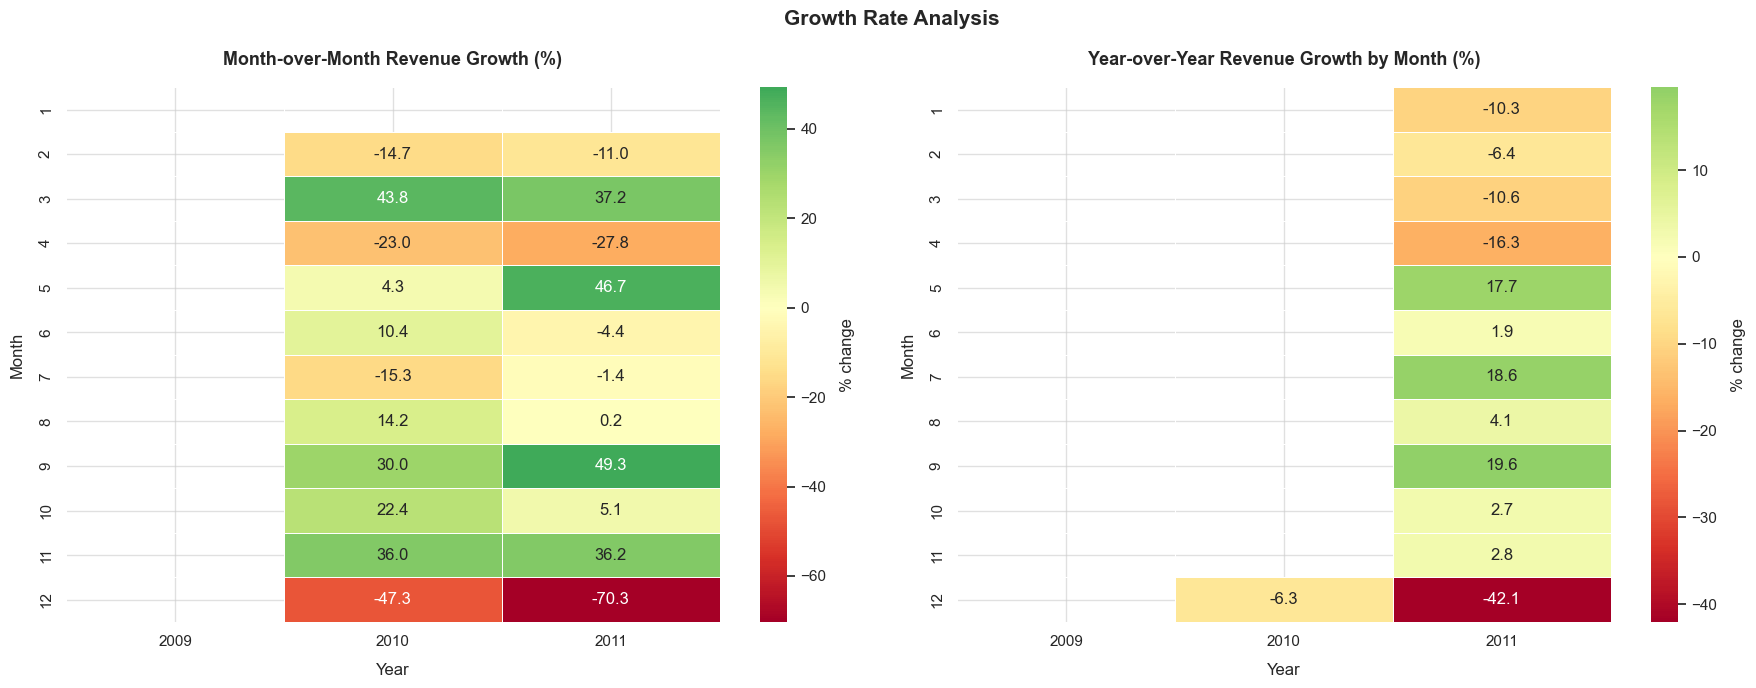

In [36]:
monthly['MoM'] = monthly.groupby('year')['revenue'].pct_change() * 100
monthly['YoY'] = monthly.groupby('month')['revenue'].pct_change() * 100

pivot_mom = monthly.pivot(index='month', columns='year', values='MoM')
pivot_yoy = monthly.pivot(index='month', columns='year', values='YoY')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pivot_mom, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': '% change'})
axes[0].set_title('Month-over-Month Revenue Growth (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Month')

sns.heatmap(pivot_yoy, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '% change'})
axes[1].set_title('Year-over-Year Revenue Growth by Month (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Month')

plt.suptitle('Growth Rate Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

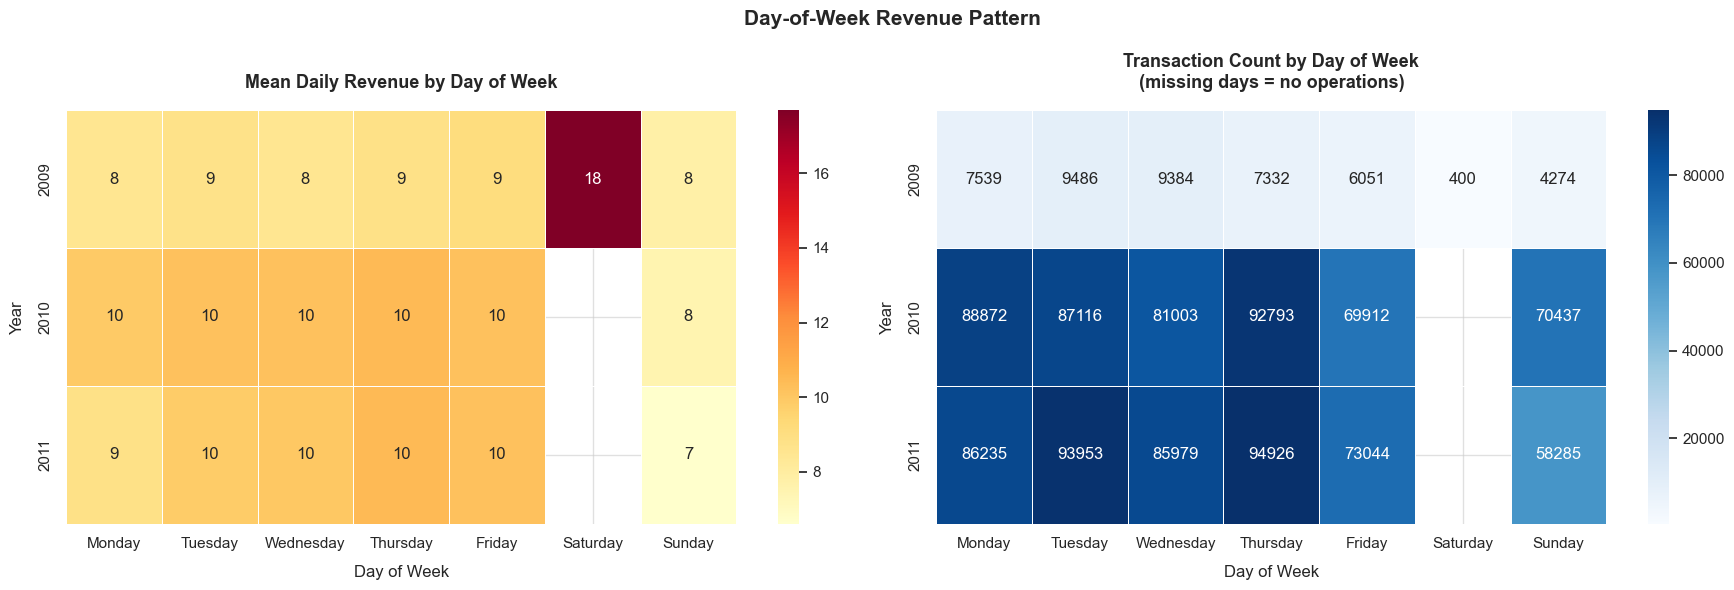

In [37]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = (
    df.groupby(['year', 'day_of_week'])['revenue']
    .agg(['median', 'sum', 'count'])
    .reset_index()
)
dow['day_of_week'] = pd.Categorical(dow['day_of_week'], categories=dow_order, ordered=True)
dow = dow.sort_values(['year', 'day_of_week'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean revenue per day-of-week (heatmap: year × dow)
pivot_dow_mean = dow.pivot(index='year', columns='day_of_week', values='median')
sns.heatmap(pivot_dow_mean, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Mean Daily Revenue by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day of Week'); axes[0].set_ylabel('Year')

# Transaction count heatmap to spot operational patterns
pivot_dow_count = dow.pivot(index='year', columns='day_of_week', values='count')
sns.heatmap(pivot_dow_count, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Transaction Count by Day of Week\n(missing days = no operations)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week'); axes[1].set_ylabel('Year')

plt.suptitle('Day-of-Week Revenue Pattern', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

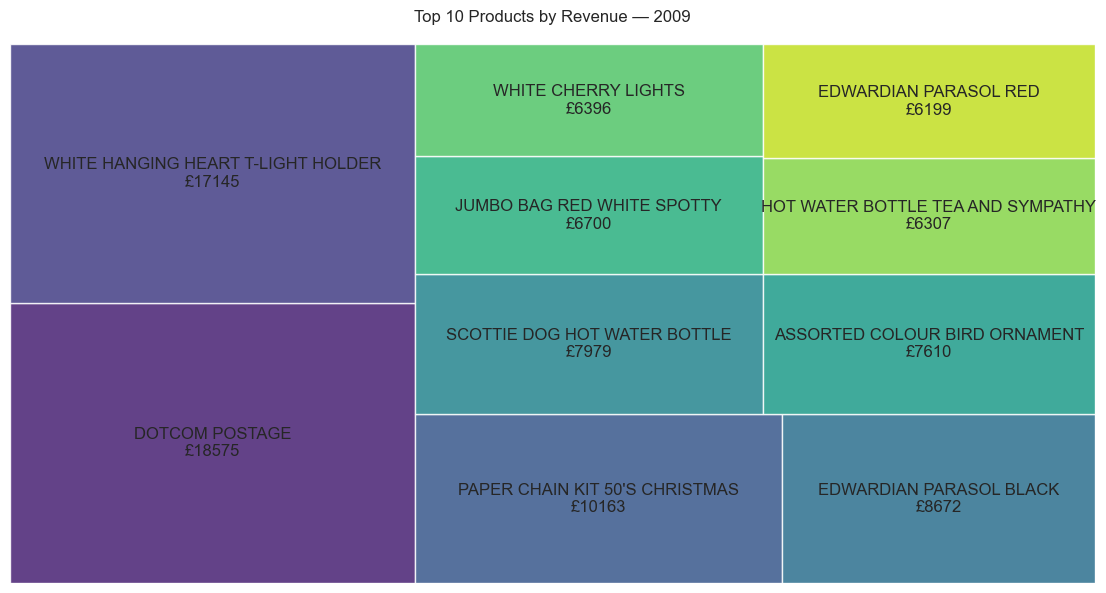

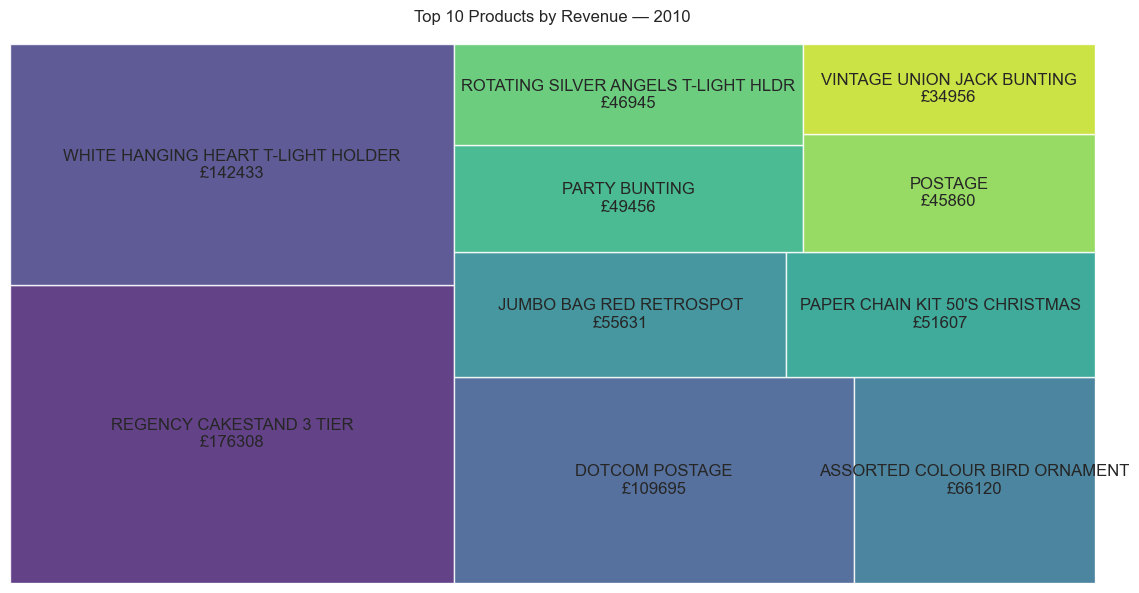

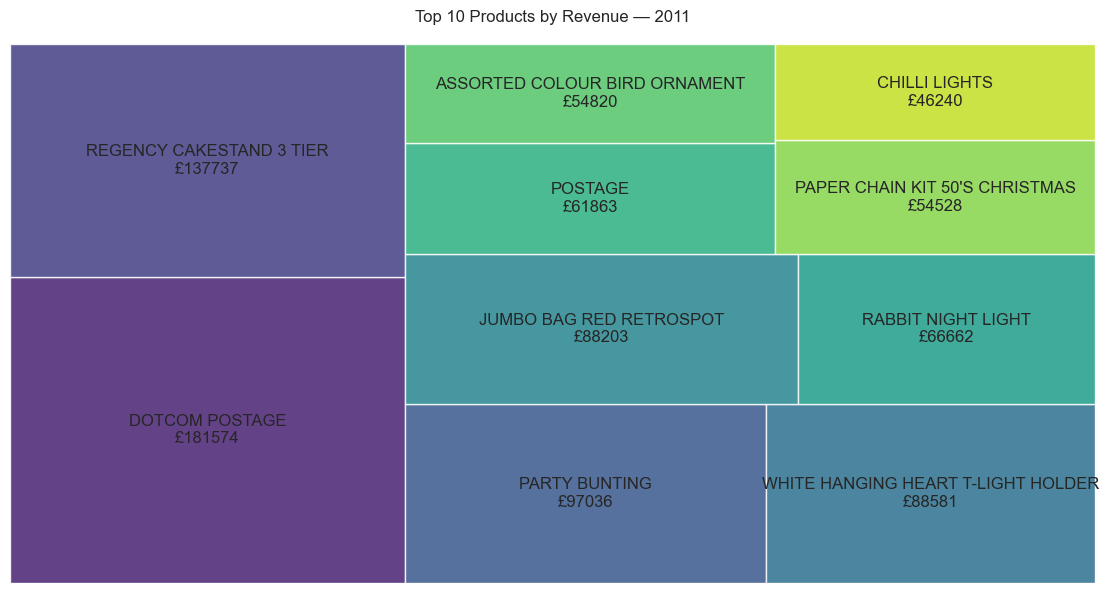

In [38]:
year_product_rev = df.groupby(['year', 'stock_code', 'description'])['revenue'].sum().reset_index()
year_product_rev = year_product_rev.sort_values(['year', 'revenue'], ascending=[True, False])

top_10_per_year = year_product_rev.groupby('year').head(10).reset_index()
top_10_per_year = top_10_per_year.drop(columns='index').copy()

for year in top_10_per_year['year'].unique():
    subset = top_10_per_year[top_10_per_year['year'] == year].sort_values('revenue', ascending=False)

    plt.figure(figsize=(14, 7))
    squarify.plot(
        sizes=subset['revenue'],
        label=subset['description'] + '\n£' + subset['revenue'].round(0).astype(int).astype(str),
        color=sns.color_palette('viridis', len(subset)),
        alpha=0.85
    )
    plt.title(f'Top 10 Products by Revenue — {year}')
    plt.axis('off')
    plt.show()

-  top 10 bestsellers per year, can be used in product analysis;

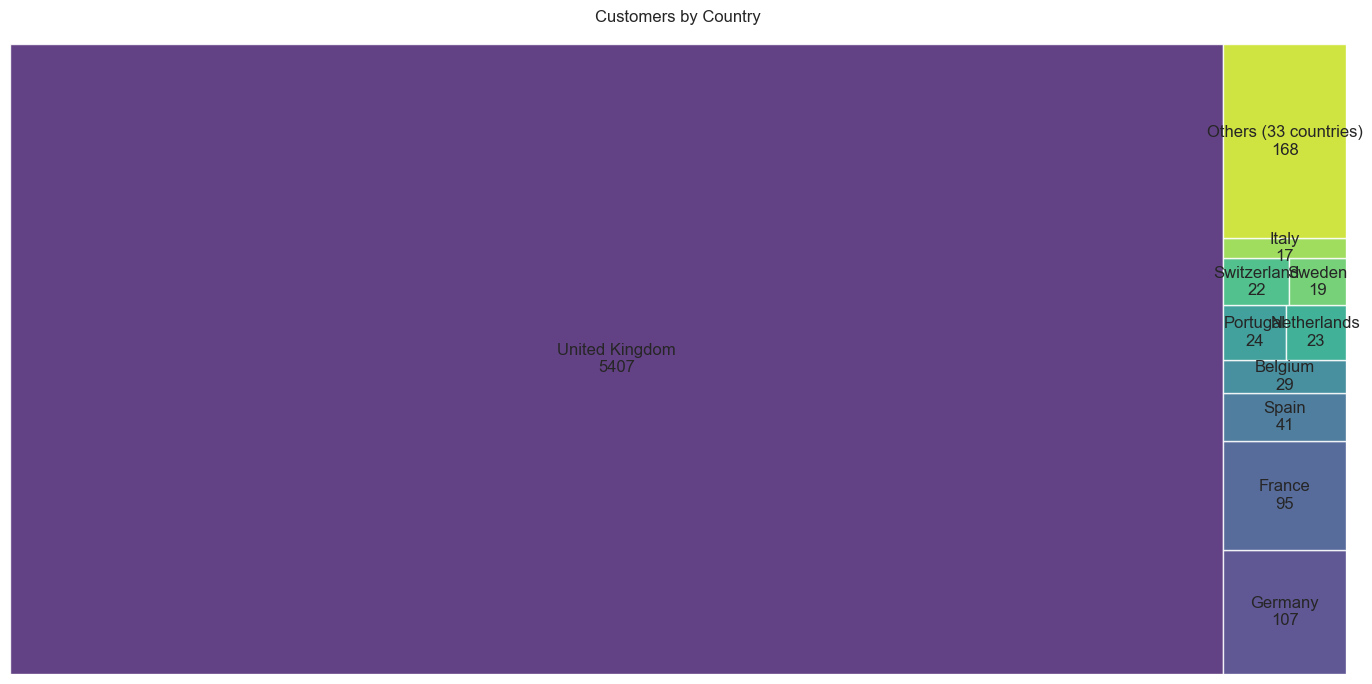

In [39]:
customer_unique = (
        df.groupby('country')['customer_id']
        .nunique()
        .reset_index()
        .sort_values('customer_id', ascending=False)
    )

total_countries = len(customer_unique)
top_n=10
year=None

if total_countries <= 30:
    plot_df = customer_unique.copy()
else:
    top = customer_unique.head(top_n)
    rest = customer_unique.iloc[top_n:]
    others_row = pd.DataFrame([{
        'country': f'Others ({len(rest)} countries)',
        'customer_id': rest['customer_id'].sum()
    }])
    plot_df = pd.concat([top, others_row], ignore_index=True)

plt.figure(figsize=(14, 7))
squarify.plot(
    sizes=plot_df['customer_id'],
    label=plot_df['country'] + '\n' + plot_df['customer_id'].astype(str),
    color=sns.color_palette('viridis', len(plot_df)),
    alpha=0.85,
)
title = 'Customers by Country'
if year:
    title += f' — {year}'
plt.title(title)
plt.axis('off')
plt.tight_layout()
plt.show()

- UK has 5329 unique customers, the biggest customer base, the second is Germany (107), followed by France (93), then Spain (38) and finally the others;

2026-04-26 19:54:22 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 19:54:22 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


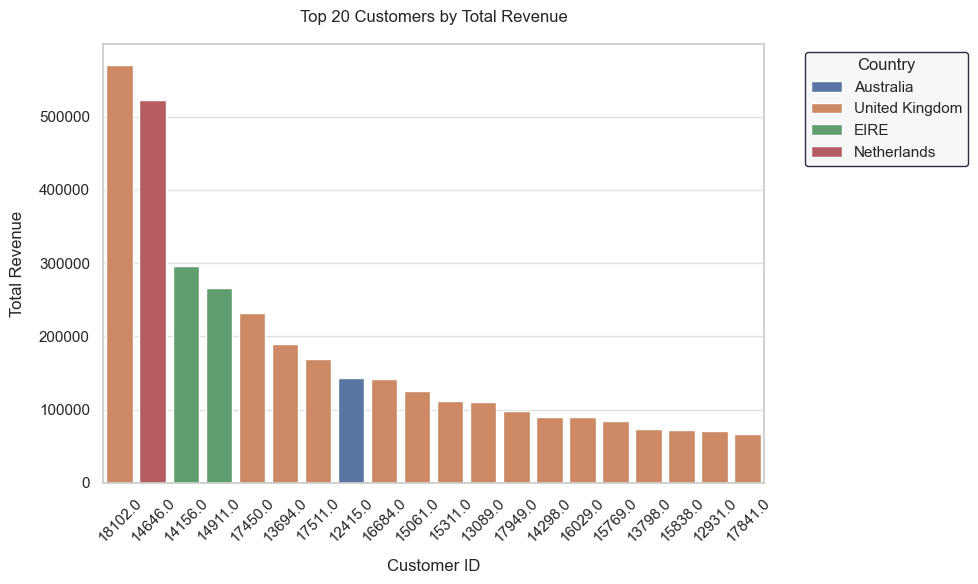

In [40]:
customers_revenue = df.groupby(['customer_id', 'country'])['revenue'].sum().reset_index()
sorted_data = customers_revenue.sort_values(by='revenue', ascending=False).head(20)

sns.barplot(
    x='customer_id', 
    y='revenue', 
    hue='country', 
    data=customers_revenue.sort_values(by='revenue', ascending=False).head(20),
    order=sorted_data['customer_id']
    )

plt.title('Top 20 Customers by Total Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.show()

- 16 customers in top 20 are from UK, 2 from EIRE, 1 from Australia, 1 from Netherlands;
- very top customers from Netherlands, UK and EIRE are the most valuable, as they contribute to the revenue the most;
- even tough, the stable top customers also valuable, and loss of one will not contribute to a big revenue loss.

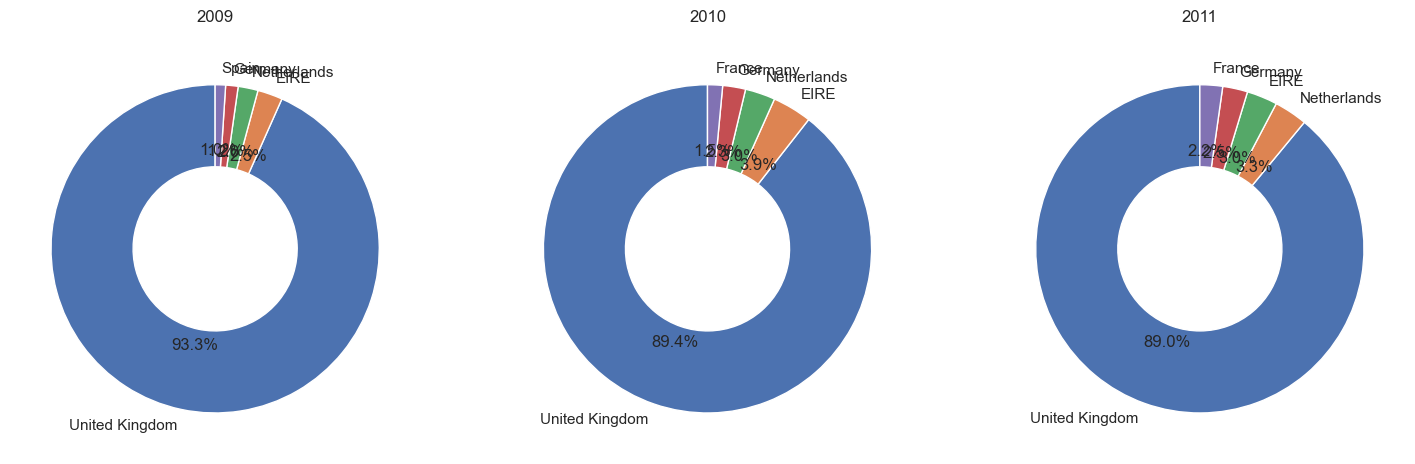

In [41]:
year_country_rev = (
    df.groupby(['year', 'country'])['revenue']
      .sum()
      .reset_index()
)

top_5_per_year = (
    year_country_rev
    .sort_values(['year', 'revenue'], ascending=[True, False])
    .groupby('year')
    .head(5)
)

years = sorted(top_5_per_year['year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 6))

if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    data_year = top_5_per_year[top_5_per_year['year'] == year]
    ax.pie(data_year['revenue'], labels=data_year['country'], autopct='%1.1f%%',
           startangle=90, wedgeprops=dict(width=0.5))
    ax.set_title(f'{year}')


- the money flow mostly comes from UK (approx. 88.5%); should consider segmentation separated for UK and Others;
- the share is shifting from the UK to other countires from 92.5% (only 1 month) to 88.7% and to 87.8%;

In [42]:
for col in ['quantity', 'price', 'revenue']:
    stat, p = stats.normaltest(df[col].dropna())
    print(f"{col}: p-value = {p} ({'Normal' if p > 0.05 else 'Non-normal'})")

pearson_corr, pearson_p = stats.pearsonr(df['quantity'], df['revenue'])
spearman_corr, spearman_p = stats.spearmanr(df['quantity'], df['revenue'])

print(f"Pearson: r={pearson_corr:.3f}, p={pearson_p:.2e}")
print(f"Spearman: ρ={spearman_corr:.3f}, p={spearman_p:.2e}")

quantity: p-value = 0.0 (Non-normal)
price: p-value = 0.0 (Non-normal)
revenue: p-value = 0.0 (Non-normal)
Pearson: r=0.799, p=0.00e+00
Spearman: ρ=0.694, p=0.00e+00


- alreadt been seen from log usage that distribution is non-normal and right skewed, so using spearman is better, as pearson is sensitive to outliers;

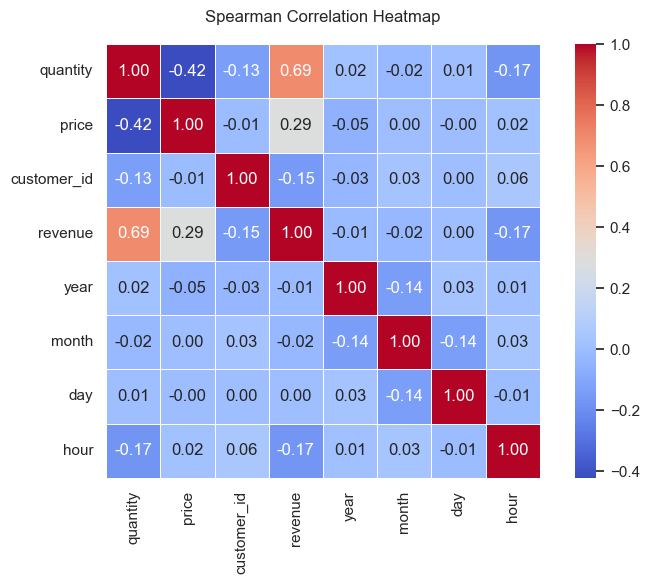

In [43]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Spearman Correlation Heatmap')
plt.tight_layout()
plt.show()

- more money comes from qty (.69), rather than from price (.29), plus they have negative corr that proves the point (-.42);

In [44]:
df

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue,year,month,day,hour,day_of_week,date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom,83.400,2009,12,1,7,Tuesday,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom,81.000,2009,12,1,7,Tuesday,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom,81.000,2009,12,1,7,Tuesday,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom,100.800,2009,12,1,7,Tuesday,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom,30.000,2009,12,1,7,Tuesday,2009-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,"12,680.000",France,12.600,2011,12,9,12,Friday,2011-12-09
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,"12,680.000",France,16.600,2011,12,9,12,Friday,2011-12-09
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,"12,680.000",France,16.600,2011,12,9,12,Friday,2011-12-09
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.950,"12,680.000",France,14.850,2011,12,9,12,Friday,2011-12-09


In [45]:
print(f"Before: {len(df)}")
df = df.dropna(subset=['customer_id'])
df['customer_id'] = df['customer_id'].astype(int)
print(f"After dropping null customer_id: {len(df)}")

Before: 1027021
After dropping null customer_id: 797815


C:\Users\zxrco\AppData\Local\Temp\ipykernel_3828\3056152199.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['customer_id'] = df['customer_id'].astype(int)


- dropped for rfm analysis;

In [47]:
df.drop(columns=['day_of_week', 'date', 'day', 'hour'], inplace=True)

pd_to_csv_path = os.path.join('..', 'data', '02_processed', 'base_retail.csv')

os.makedirs(os.path.dirname(pd_to_csv_path), exist_ok=True)
df.to_csv(pd_to_csv_path, index=False)

print(f"Saved to: {pd_to_csv_path}")

C:\Users\zxrco\AppData\Local\Temp\ipykernel_3828\3349491454.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['day_of_week', 'date', 'day', 'hour'], inplace=True)


Saved to: ..\data\02_processed\base_retail.csv


- saved processed base dataset for further feature engineering and eda;
- metadata is generated as it helps both humans and AI tools (in my case Copilot) understand schema;

## Summary of Initial EDA and Data Cleaning

### Key Data Quality Issues Identified:
- **22.8%** of customer IDs were missing (likely guest transactions)
- **0.4%** of product descriptions were missing  
- **34,000** duplicate records identified
- **23,000** entries with negative quantities (returns/cancellations)
- **6,000** entries with negative prices (data quality issues)
- Non-product transactions included (postage, fees, adjustments)

### Data Cleaning Steps Applied:
1. **Removed invalid transactions**: Zero/negative prices, non-product codes (POST, DOT, M, D, C2, etc.)
2. **Handled missing values**: Dropped records with missing customer IDs (cannot perform customer-level RFM without ID)
3. **Return/cancellation logic**: Invoice codes starting with 'C' indicate cancellations
4. **Revenue consistency**: Removed customers with negative total revenue balance
5. **Deduplication**: Removed 34k duplicate records
6. **Feature engineering**: Created `revenue` column (quantity × price), extracted `year` and `month`

### Key Insights:
- **Geographic concentration**: UK dominates with **~88.5%** of total revenue
- **Seasonality patterns**: Revenue spikes in **October-November** (pre-holiday surge), drops in December
- **Revenue drivers**: Quantity drives revenue more than price (correlation: 0.69 vs 0.29)
- **Price-quantity relationship**: **Negative correlation (-0.42)** suggests volume discounting
- **Dataset timespan**: December 2009 - December 2011 (2 full years)
- **Order behavior**: Median order size consistently 2-12 units across years

### Next Steps:
The cleaned dataset has been saved to `../data/02_processed/base_retail.csv` and is ready for:
1. RFM metric calculations & other feature engineering
2. Customer segmentation modeling

*Note: The dataset maintains both positive and negative quantities to preserve return/cancellation patterns for comprehensive customer behavior analysis.*